In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import sys
sys.path.append('../../pybeh')
sys.path.append('../../CourierReinstate1')
import cmlreaders as cml
from cmldask import CMLDask as da
from dask.distributed import wait, as_completed
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import xarray as xr
import pandas_to_pybeh as pb
import scipy as scp
import re
import math
import pickle
import gc
from scipy import stats
from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter
from statsmodels.stats.multitest import multipletests
from compute_scalp_features import create_baseline_events
from BehavioralFunctions import *

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
%matplotlib inline
import importlib
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

In [5]:
experiment = 'ValueCourier'
subject = 'LTP606'
data = cml.get_data_index(kind = 'ltp')
data = data[(data['experiment']==experiment) & (data['subject']==subject)].sort_values('session').reset_index()
df_sess = data.iloc[0]

In [6]:
reader = cml.CMLReader(subject=df_sess['subject'], experiment=df_sess['experiment'], session=df_sess['session'])
evs = reader.load('task_events')

In [9]:
with open("all_items.txt") as f:
    pool_raw = [w.strip() for w in f if w.strip()]
if pool_raw and pool_raw[0].lower() == "word":
    pool_raw = pool_raw[1:]

pool = [w.upper() for w in pool_raw]
pool_map = {w: i+1 for i, w in enumerate(pool)}

evs["itemno"] = evs["item"].map(pool_map)

In [10]:
# Convert to DataFrame
value_recalls = evs[evs.type == "VALUE_RECALL"] 
words = evs[evs.type == "WORD"]
rec_words = evs[evs.type == "REC_WORD"]
rec_vv_words = evs[evs.type == "REC_WORD_VV"]

# WORD --> storepointtype, recalled--> VALUE_RECALL, REC_WORD, REC_WORD_VV
word_trial_to_storepointtype = words.set_index("trial")["storepointtype"].to_dict()
word_trial_to_recalled = words.set_index("trial")["recalled"].to_dict()
for event_type in ["VALUE_RECALL", "REC_WORD", "REC_WORD_VV"]:
    subset = evs[evs.type == event_type]
    for idx, row in subset.iterrows():
        trial = row["trial"]
        if trial in word_trial_to_storepointtype:
            evs.at[idx, "storepointtype"] = word_trial_to_storepointtype[trial]
        if trial in word_trial_to_recalled:
            evs.at[idx, "recalled"] = word_trial_to_recalled[trial]

# VALUE_RECALL --> actualvalue, valuerecall --> WORD, `REC_WORD`, REC_WORD_VV
valuerecall_trial_to_actualvalue = value_recalls.set_index("trial")["actualvalue"].to_dict()
valuerecall_trial_to_valuerecall = value_recalls.set_index("trial")["valuerecall"].to_dict()

# --- Apply to multi-row event types ---
for event_type in ["WORD", "REC_WORD", "REC_WORD_VV"]:
    subset = evs[evs.type == event_type]
    for idx, row in subset.iterrows():
        trial = row["trial"]

        # actualvalue
        if trial in valuerecall_trial_to_actualvalue:
            evs.at[idx, "actualvalue"] = valuerecall_trial_to_actualvalue[trial]

        # valuerecall
        if trial in valuerecall_trial_to_valuerecall:
            evs.at[idx, "valuerecall"] = valuerecall_trial_to_valuerecall[trial]

In [38]:
# Overall recall probability

word_evs = evs[evs['type'] == 'WORD']
recall_prob = word_evs['recalled'].mean()
sub_recall = pd.DataFrame({'subject': [word_evs['subject'].iloc[0]], 'Recall_Probability': [recall_prob]})
sub_recall

,subject,Recall_Probability
0,LTP606,0.36


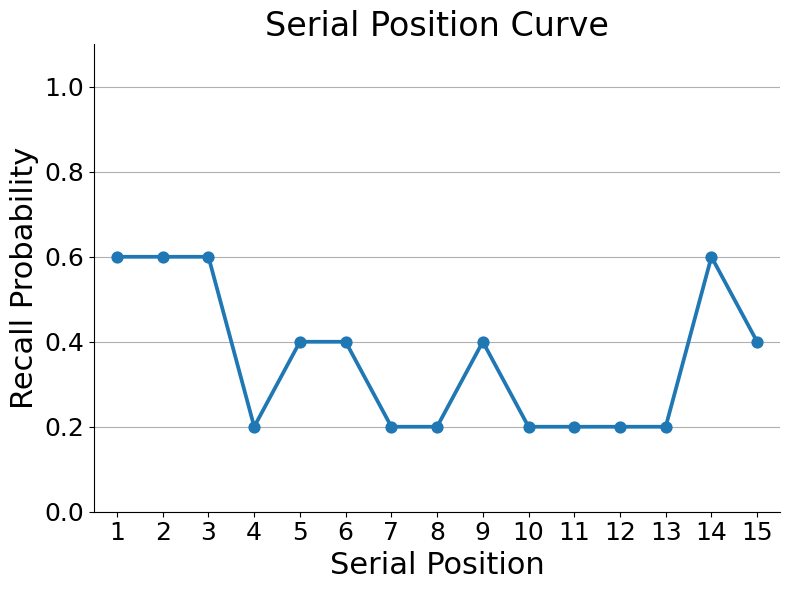

In [24]:
# Serial position curve

spc_df = word_evs.groupby('serialpos', as_index=False)['recalled'].mean()

fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

sns.pointplot(data=spc_df, x='serialpos', y='recalled', ax=ax)

ax.set_title('Serial Position Curve', fontsize=24)
ax.set_xlabel('Serial Position', fontsize=22)
ax.set_ylabel('Recall Probability', fontsize=22)
ax.tick_params(labelsize=18)
ax.set_ylim(0, 1.1)

ax.yaxis.grid()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

plt.tight_layout()
plt.show()

In [26]:
# Probability of first recall

recword = evs.query('type == "REC_WORD"')
recword['pos'] = recword.groupby('trial').cumcount()
first_recall_df = recword.query('pos == 0 and serialpos >= 0')
first_recall_df = (first_recall_df.groupby('serialpos').size().reset_index(name='recalled'))
n_lists = recword['trial'].nunique()
first_recall_df['prob'] = first_recall_df['recalled'] / n_lists

first_recall_df

,serialpos,recalled,prob
0,1,1,0.2
1,3,1,0.2
2,13,1,0.2
3,14,2,0.4


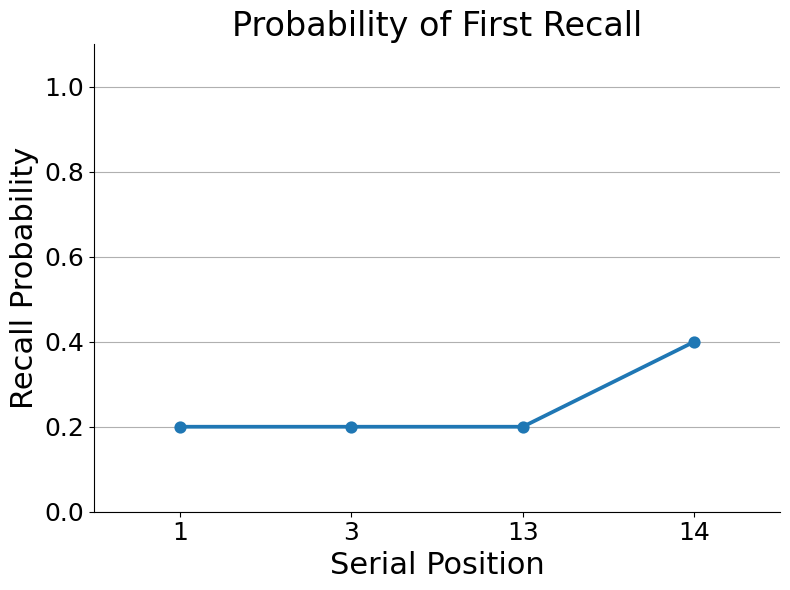

In [27]:
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

sns.pointplot(data=first_recall_df, x='serialpos', y='prob', ax=ax)

ax.set_title('Probability of First Recall', fontsize=24)
ax.set_xlabel('Serial Position', fontsize=22)
ax.set_ylabel('Recall Probability', fontsize=22)
ax.tick_params(labelsize=18)
ax.set_ylim(0, 1.1)

ax.yaxis.grid()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
# Lag CRP

crp_df = evs.groupby(['subject']).apply(
    pb.pd_crp,
    itemno_column='itemno',
    list_index=['subject', 'session', 'trial'],
    lag_num=5).reset_index()

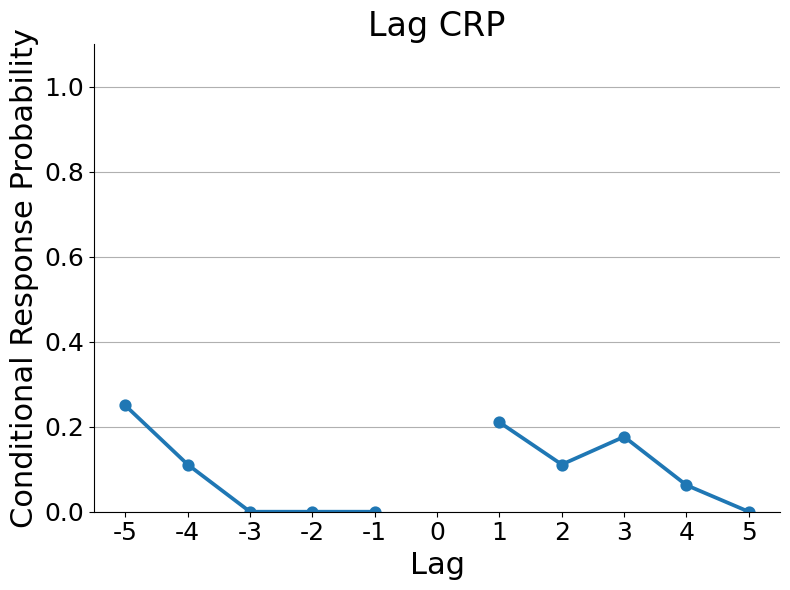

In [36]:
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

sns.pointplot(data=crp_df, x='lag', y='prob', ax=ax)

ax.set_title('Lag CRP', fontsize=24)
ax.set_xlabel('Lag', fontsize=22)
ax.set_ylabel('Conditional Response Probability', fontsize=22)
ax.tick_params(labelsize=18)
ax.set_ylim(0, 1.1)

ax.yaxis.grid()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)

plt.tight_layout()
plt.show()

In [39]:
merged_df = get_mixed_model_fitted_error(evs, sub_recall)
plot_error_diff_vs_binned_cluster_score(merged_df)

  subject  session  trial  actualvalue  valuerecall  item_count  \
0  LTP606        0      0    14.066667           15          15   
1  LTP606        0      1    40.933334           40          15   
2  LTP606        0      2    16.133333           14          15   
3  LTP606        0      3    17.000000           15          15   
4  LTP606        0      4    34.933334           22          15   

  storepointtype  abs_error  
0       Temporal   0.933333  
1       Temporal   0.933334  
2         random   2.133333  
3         random   2.000000  
4       Temporal  12.933334  
abs_error             0
storepointtype        0
TC                    0
Recall_Probability    0
subject               0
dtype: int64
N rows in merged: 5


LinAlgError: Singular matrix

In [40]:
sub_error_df = get_mixed_model_fitted_error_conditions(evs)
sub_error_df

,subject,storepointtype,err_all,err_middle,err_correct,err_corr_mid,TC
0,LTP606,Temporal,4.933333,5.266667,3.322222,4.722222,0.505905
1,LTP606,random,2.066667,3.950000,2.940476,4.333333,0.505905


In [41]:
plot_error_vs_cluster_score_conditions(sub_error_df)

ValueError: Bin edges must be unique: array([0.50590521, 0.50590521, 0.50590521, 0.50590521]).
You can drop duplicate edges by setting the 'duplicates' kwarg